In [175]:
import numpy as np
import pandas as pd

In [176]:
df = pd.read_csv('spam.csv',encoding='latin-1')

In [177]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
1758,ham,Sorry i'm not free...,NaN,NaN,NaN
4146,ham,Pls help me tell sura that i'm expecting a bat...,NaN,NaN,NaN
3803,ham,"No dude, its not fake..my frnds got money, tht...",NaN,NaN,NaN
868,spam,Hello. We need some posh birds and chaps to us...,NaN,NaN,NaN
2959,ham,Sir send to group mail check it.,NaN,NaN,NaN


In [178]:
df.shape

(5572, 5)

In [179]:
# Data cleaning
# EDA
# Text Preprocessing
# Model Building
# Evaluation
# Improvement
# Website
# Deploy

# DataCleaning

In [180]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [181]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [182]:
df.sample(5)

,v1,v2
2902,ham,Tell me pa. How is pain de.
3397,ham,It only does simple arithmetic not percentages.
1425,ham,I'll be at mu in like &lt;#&gt; seconds
1081,ham,Can u get pic msgs to your phone?
1502,ham,Don no da:)whats you plan?


In [183]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
751,spam,You have an important customer service announc...
4120,ham,Yunny... I'm goin to be late
1764,spam,Hi 07734396839 IBH Customer Loyalty Offer: The...
1311,ham,U r too much close to my heart. If u go away i...
3103,ham,That's y i said it's bad dat all e gals know u...


In [184]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [185]:
df['target'] = le.fit_transform(df['target'])

In [186]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [187]:
df.duplicated().sum()

403

In [188]:
df.drop_duplicates(keep='first',inplace=True)

In [189]:
df.duplicated().sum()

0

In [190]:
df.shape

(5169, 2)

# EDA

In [191]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [192]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

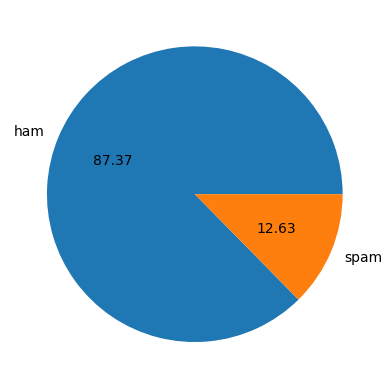

In [193]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct='%0.2f')
plt.show()

### Data is implalanced

In [194]:
df['num_char'] = df['text'].apply(len)

In [195]:
df.head()

,target,text,num_char
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [196]:
import nltk
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [197]:
df['num_sentence'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [198]:
df.head()

,target,text,num_char,num_words,num_sentence
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [199]:
df[['num_char','num_words','num_sentence']].describe()

,num_char,num_words,num_sentence
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [200]:
df[df['target']==0][['num_char','num_words','num_sentence']].describe()

,num_char,num_words,num_sentence
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [201]:
df[df['target']==1][['num_char','num_words','num_sentence']].describe()

,num_char,num_words,num_sentence
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [202]:
import seaborn as sns

<Axes: xlabel='num_char', ylabel='Count'>

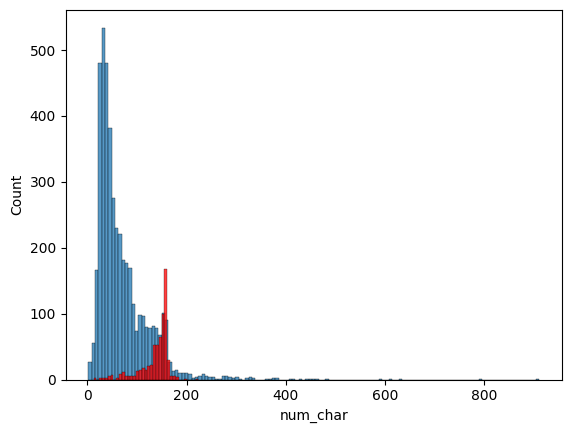

In [203]:
sns.histplot(df[df['target'] == 0]['num_char'])
sns.histplot(df[df['target'] == 1]['num_char'], color='red')

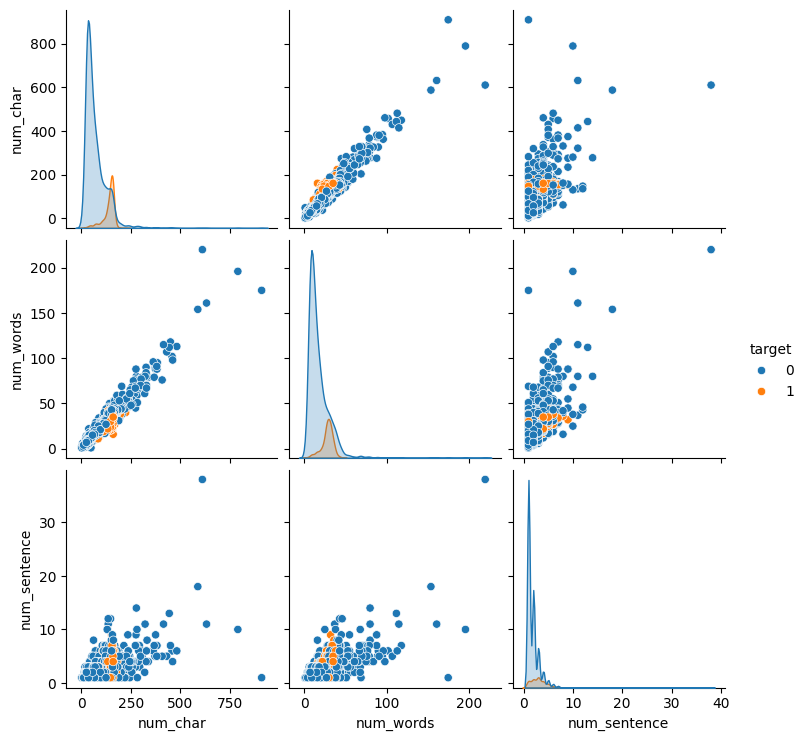

In [204]:
sns.pairplot(df,hue='target')

<Axes: >

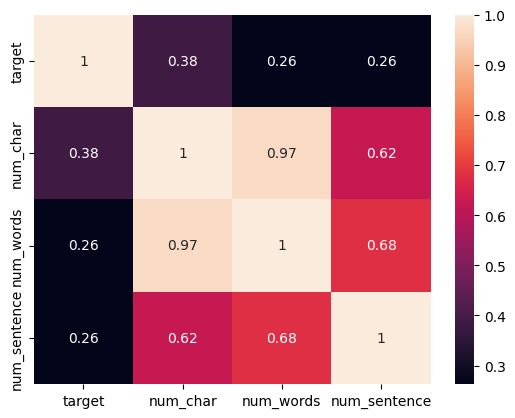

In [205]:
sns.heatmap(df[['target','num_char','num_words','num_sentence']].corr(),annot=True)

## 3. Data Preprocessing

- Lower case  
- Tokenization  
- Removing special characters  
- Removing stop words and punctuation  
- Stemming  

In [206]:
from nltk.corpus import stopwords

In [207]:
# stopwords.words('english')
from nltk.stem.porter import PorterStemmer
import string
def transform_text(text):
    ps = PorterStemmer()
    y = []
    text = text.lower()
    text = nltk.word_tokenize(text)
    for i in text:
        if i.isalnum():
            y.append(i)
    x = []
    for i in y:
        if i not in stopwords.words('english') and i not in string.punctuation:
            x.append(ps.stem(i))
            
    return x

In [208]:
transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

['gon',
 'na',
 'home',
 'soon',
 'want',
 'talk',
 'stuff',
 'anymor',
 'tonight',
 'k',
 'cri',
 'enough',
 'today']

In [209]:
df['transformed_text'] = df['text'].apply(transform_text)

In [210]:
df.head()

,target,text,num_char,num_words,num_sentence,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,"[go, jurong, point, crazi, avail, bugi, n, gre..."
1,0,Ok lar... Joking wif u oni...,29,8,2,"[ok, lar, joke, wif, u, oni]"
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,"[free, entri, 2, wkli, comp, win, fa, cup, fin..."
3,0,U dun say so early hor... U c already then say...,49,13,1,"[u, dun, say, earli, hor, u, c, alreadi, say]"
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,"[nah, think, goe, usf, live, around, though]"


In [211]:
df.head()

,target,text,num_char,num_words,num_sentence,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,"[go, jurong, point, crazi, avail, bugi, n, gre..."
1,0,Ok lar... Joking wif u oni...,29,8,2,"[ok, lar, joke, wif, u, oni]"
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,"[free, entri, 2, wkli, comp, win, fa, cup, fin..."
3,0,U dun say so early hor... U c already then say...,49,13,1,"[u, dun, say, earli, hor, u, c, alreadi, say]"
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,"[nah, think, goe, usf, live, around, though]"


In [212]:
df[df['target']==1]['transformed_text'].tolist()[:3]

[['free',
  'entri',
  '2',
  'wkli',
  'comp',
  'win',
  'fa',
  'cup',
  'final',
  'tkt',
  '21st',
  'may',
  'text',
  'fa',
  '87121',
  'receiv',
  'entri',
  'question',
  'std',
  'txt',
  'rate',
  'c',
  'appli',
  '08452810075over18'],
 ['freemsg',
  'hey',
  'darl',
  '3',
  'week',
  'word',
  'back',
  'like',
  'fun',
  'still',
  'tb',
  'ok',
  'xxx',
  'std',
  'chg',
  'send',
  'rcv'],
 ['winner',
  'valu',
  'network',
  'custom',
  'select',
  'receivea',
  'prize',
  'reward',
  'claim',
  'call',
  'claim',
  'code',
  'kl341',
  'valid',
  '12',
  'hour']]

In [213]:
spam_corpus = []
for msg in df[df['target']==1]['transformed_text'].tolist():
    for word in msg:
        spam_corpus.append(word)

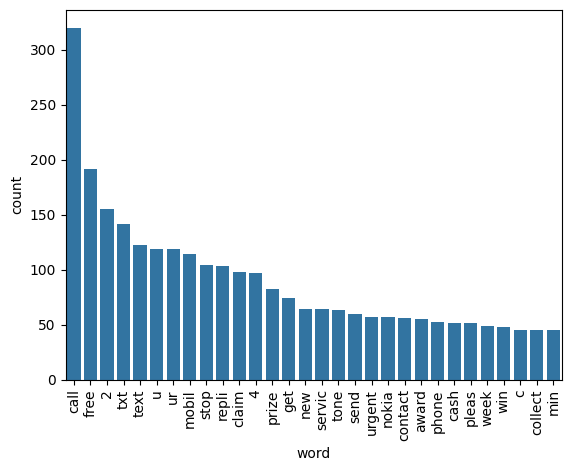

In [214]:
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
c = Counter(spam_corpus).most_common(30)
df_common = pd.DataFrame(c,columns=['word','count'])
sns.barplot(x='word', y='count', data=df_common)
plt.xticks(rotation=90)
plt.show()

In [215]:
len(spam_corpus)

9939

In [216]:
ham_corpus = []
for msg in df[df['target']==0]['transformed_text'].tolist():
    for word in msg:
        ham_corpus.append(word)

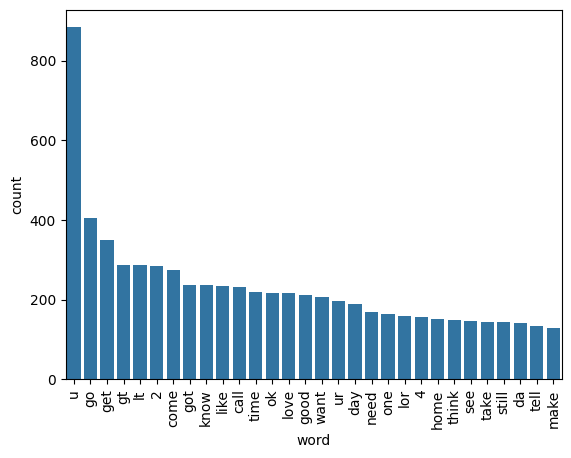

In [217]:
c = Counter(ham_corpus).most_common(30)
df_common = pd.DataFrame(c,columns=['word','count'])
sns.barplot(x='word', y='count', data=df_common)
plt.xticks(rotation=90)
plt.show()

# Model Building

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
# 2
tfidf = TfidfVectorizer(max_features=3000)
# 1
# tfidf = TfidfVectorizer()

In [219]:
df['transformed_text'].head()

0    [go, jurong, point, crazi, avail, bugi, n, gre...
1                         [ok, lar, joke, wif, u, oni]
2    [free, entri, 2, wkli, comp, win, fa, cup, fin...
3        [u, dun, say, earli, hor, u, c, alreadi, say]
4         [nah, think, goe, usf, live, around, though]
Name: transformed_text, dtype: object

In [220]:
df['transformed_text'] = df['transformed_text'].apply(lambda x: " ".join(x))

In [221]:
df['transformed_text'].head()

0    go jurong point crazi avail bugi n great world...
1                                ok lar joke wif u oni
2    free entri 2 wkli comp win fa cup final tkt 21...
3                  u dun say earli hor u c alreadi say
4                 nah think goe usf live around though
Name: transformed_text, dtype: object

In [222]:
X = cv.fit_transform(df['transformed_text']).toarray()
X_tfidf = tfidf.fit_transform(df['transformed_text']).toarray()

In [223]:
X.shape

(5169, 6708)

In [224]:
X_tfidf.shape

(5169, 6708)

In [225]:
y = df['target'].values

In [226]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)
X_traintfidf, X_testtfidf, y_traintfidf, y_testtfidf = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=2
)

In [252]:
X_traintfidf_n, X_testtfidf_n, y_traintfidf_n, y_testtfidf_n = train_test_split(
    X_n, y_n, test_size=0.2, random_state=2
)

In [228]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score

In [253]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

gnbtfidf = GaussianNB()
mnbtfidf = MultinomialNB()
bnbtfidf = BernoulliNB()

In [254]:
gnb.fit(X_train,y_train)

,priors,None
,var_smoothing,1e-09


In [ ]:
gnbtfidf.fit(X_traintfidf,y_traintfidf)

,priors,None
,var_smoothing,1e-09


In [256]:
mnb.fit(X_train,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [ ]:
mnbtfidf.fit(X_traintfidf,y_traintfidf)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [258]:
bnb.fit(X_train,y_train)

,alpha,1.0
,force_alpha,True
,binarize,0.0
,fit_prior,True
,class_prior,None


In [ ]:
bnbtfidf.fit(X_traintfidf,y_traintfidf)

,alpha,1.0
,force_alpha,True
,binarize,0.0
,fit_prior,True
,class_prior,None


In [260]:
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))
print(precision_score(y_test, y_pred1))

0.8800773694390716
[[792 104]
 [ 20 118]]
0.5315315315315315


In [ ]:
y_pred2 = gnbtfidf.predict(X_testtfidf)
print(accuracy_score(y_testtfidf, y_pred2))
print(confusion_matrix(y_testtfidf, y_pred2))
print(precision_score(y_testtfidf, y_pred2))

0.8762088974854932
[[786 110]
 [ 18 120]]
0.5217391304347826


In [262]:
y_pred3 = mnb.predict(X_test)
print(accuracy_score(y_test, y_pred3))
print(confusion_matrix(y_test, y_pred3))
print(precision_score(y_test, y_pred3))

0.9642166344294004
[[871  25]
 [ 12 126]]
0.8344370860927153


In [ ]:
y_pred4 = mnbtfidf.predict(X_testtfidf)
print(accuracy_score(y_testtfidf, y_pred4))
print(confusion_matrix(y_testtfidf, y_pred4))
print(precision_score(y_testtfidf, y_pred4))

0.9690522243713733
[[876  20]
 [ 12 126]]
0.863013698630137


In [264]:
y_pred5 = bnb.predict(X_test)
print(accuracy_score(y_test, y_pred5))
print(confusion_matrix(y_test, y_pred5))
print(precision_score(y_test, y_pred5))

0.9700193423597679
[[893   3]
 [ 28 110]]
0.9734513274336283


In [241]:
y_pred6 = bnbtfidf.predict(X_testtfidf)
print(accuracy_score(y_testtfidf, y_pred6))
print(confusion_matrix(y_testtfidf, y_pred6))
print(precision_score(y_testtfidf, y_pred6))

0.9700193423597679
[[893   3]
 [ 28 110]]
0.9734513274336283


In [242]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [243]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [244]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [245]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [246]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9264990328820116, 0.7421875)

In [163]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9264990328820116
Precision -  0.7421875
For  KN
Accuracy -  0.9061895551257253
Precision -  1.0
For  NB
Accuracy -  0.9642166344294004
Precision -  0.8344370860927153
For  DT
Accuracy -  0.9264990328820116
Precision -  0.9428571428571428
For  LR
Accuracy -  0.9709864603481625
Precision -  0.9736842105263158
For  RF
Accuracy -  0.971953578336557
Precision -  1.0
For  AdaBoost
Accuracy -  0.9197292069632496
Precision -  0.9365079365079365
For  BgC
Accuracy -  0.9622823984526112
Precision -  0.9159663865546218
For  ETC
Accuracy -  0.97678916827853
Precision -  0.9913793103448276
For  GBDT
Accuracy -  0.9439071566731141
Precision -  0.9444444444444444
For  xgb
Accuracy -  0.9738878143133463
Precision -  0.9743589743589743


In [164]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.906190,1.000000
5,RF,0.971954,1.000000
8,ETC,0.976789,0.991379
10,xgb,0.973888,0.974359
4,LR,0.970986,0.973684
9,GBDT,0.943907,0.944444
3,DT,0.926499,0.942857
6,AdaBoost,0.919729,0.936508
7,BgC,0.962282,0.915966
2,NB,0.964217,0.834437


In [165]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")
performance_df1

,Algorithm,variable,value
0,KN,Accuracy,0.906190
1,RF,Accuracy,0.971954
2,ETC,Accuracy,0.976789
3,xgb,Accuracy,0.973888
4,LR,Accuracy,0.970986
5,GBDT,Accuracy,0.943907
6,DT,Accuracy,0.926499
7,AdaBoost,Accuracy,0.919729
8,BgC,Accuracy,0.962282
9,NB,Accuracy,0.964217


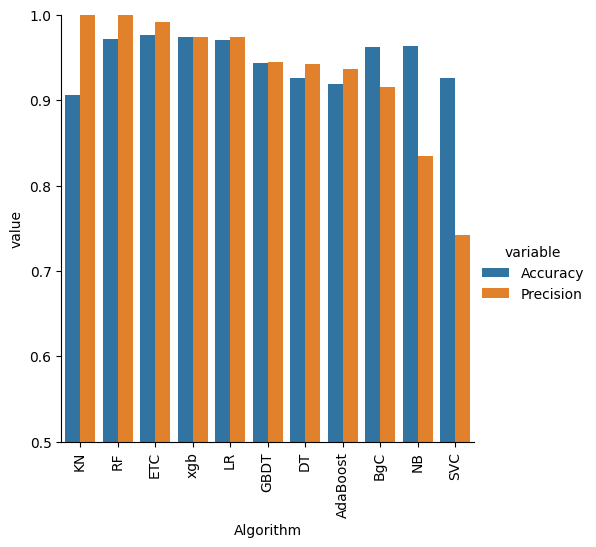

In [166]:
sns.catplot(x = 'Algorithm', y='value', 
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

# Improving Model

In [247]:
# before applying Max_iter in tfidf vectorizor
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_traintfidf,y_traintfidf,X_testtfidf,y_testtfidf)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9729206963249516
Precision -  0.9741379310344828
For  KN
Accuracy -  0.9003868471953579
Precision -  1.0
For  NB
Accuracy -  0.9593810444874274
Precision -  1.0
For  DT
Accuracy -  0.9361702127659575
Precision -  0.8461538461538461
For  LR
Accuracy -  0.9516441005802708
Precision -  0.94
For  RF
Accuracy -  0.971953578336557
Precision -  1.0
For  AdaBoost
Accuracy -  0.9245647969052224
Precision -  0.8409090909090909
For  BgC
Accuracy -  0.9584139264990329
Precision -  0.8625954198473282
For  ETC
Accuracy -  0.9729206963249516
Precision -  0.9824561403508771
For  GBDT
Accuracy -  0.9526112185686654
Precision -  0.9238095238095239
For  xgb
Accuracy -  0.9748549323017408
Precision -  0.9516129032258065


In [248]:
temp_df = pd.DataFrame({
    'Algorithm': clfs.keys(),
    'Accuracy_tfidf': accuracy_scores,
    'Precision_tfidf': precision_scores
})
# 2. Merge them together side-by-side using the Algorithm name!
performance_df = performance_df.merge(temp_df, on='Algorithm')
display(performance_df)

,Algorithm,Accuracy,Precision,Accuracy_tfidf_max_iter=3000,Precision_tfidf_max_iter=3000,Accuracy_tfidf,Precision_tfidf
0,KN,0.906190,1.000000,0.905222,1.000000,0.900387,1.000000
1,RF,0.971954,1.000000,0.975822,0.982906,0.971954,1.000000
2,ETC,0.976789,0.991379,0.974855,0.974576,0.972921,0.982456
3,xgb,0.973888,0.974359,0.967118,0.948276,0.974855,0.951613
4,LR,0.970986,0.973684,0.958414,0.970297,0.951644,0.940000
5,GBDT,0.943907,0.944444,0.946809,0.919192,0.952611,0.923810
6,DT,0.926499,0.942857,0.927466,0.811881,0.936170,0.846154
7,AdaBoost,0.919729,0.936508,0.924565,0.848837,0.924565,0.840909
8,BgC,0.962282,0.915966,0.958414,0.868217,0.958414,0.862595
9,NB,0.964217,0.834437,0.970986,1.000000,0.959381,1.000000


In [168]:
# After setting max_iter = 3000 to tfidf
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_traintfidf,y_traintfidf,X_testtfidf,y_testtfidf)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9758220502901354
Precision -  0.9747899159663865
For  KN
Accuracy -  0.9052224371373307
Precision -  1.0
For  NB
Accuracy -  0.9709864603481625
Precision -  1.0
For  DT
Accuracy -  0.9274661508704062
Precision -  0.8118811881188119
For  LR
Accuracy -  0.9584139264990329
Precision -  0.9702970297029703
For  RF
Accuracy -  0.9758220502901354
Precision -  0.9829059829059829
For  AdaBoost
Accuracy -  0.9245647969052224
Precision -  0.8488372093023255
For  BgC
Accuracy -  0.9584139264990329
Precision -  0.8682170542635659
For  ETC
Accuracy -  0.9748549323017408
Precision -  0.9745762711864406
For  GBDT
Accuracy -  0.9468085106382979
Precision -  0.9191919191919192
For  xgb
Accuracy -  0.9671179883945842
Precision -  0.9482758620689655


In [169]:
temp_df = pd.DataFrame({
    'Algorithm': clfs.keys(),
    'Accuracy_tfidf_max_iter=3000': accuracy_scores,
    'Precision_tfidf_max_iter=3000': precision_scores
})
# 2. Merge them together side-by-side using the Algorithm name!
performance_df = performance_df.merge(temp_df, on='Algorithm')
display(performance_df)

,Algorithm,Accuracy,Precision,Accuracy_tfidf_max_iter=3000,Precision_tfidf_max_iter=3000
0,KN,0.906190,1.000000,0.905222,1.000000
1,RF,0.971954,1.000000,0.975822,0.982906
2,ETC,0.976789,0.991379,0.974855,0.974576
3,xgb,0.973888,0.974359,0.967118,0.948276
4,LR,0.970986,0.973684,0.958414,0.970297
5,GBDT,0.943907,0.944444,0.946809,0.919192
6,DT,0.926499,0.942857,0.927466,0.811881
7,AdaBoost,0.919729,0.936508,0.924565,0.848837
8,BgC,0.962282,0.915966,0.958414,0.868217
9,NB,0.964217,0.834437,0.970986,1.000000


In [249]:
performance_df

,Algorithm,Accuracy,Precision,Accuracy_tfidf_max_iter=3000,Precision_tfidf_max_iter=3000,Accuracy_tfidf,Precision_tfidf
0,KN,0.906190,1.000000,0.905222,1.000000,0.900387,1.000000
1,RF,0.971954,1.000000,0.975822,0.982906,0.971954,1.000000
2,ETC,0.976789,0.991379,0.974855,0.974576,0.972921,0.982456
3,xgb,0.973888,0.974359,0.967118,0.948276,0.974855,0.951613
4,LR,0.970986,0.973684,0.958414,0.970297,0.951644,0.940000
5,GBDT,0.943907,0.944444,0.946809,0.919192,0.952611,0.923810
6,DT,0.926499,0.942857,0.927466,0.811881,0.936170,0.846154
7,AdaBoost,0.919729,0.936508,0.924565,0.848837,0.924565,0.840909
8,BgC,0.962282,0.915966,0.958414,0.868217,0.958414,0.862595
9,NB,0.964217,0.834437,0.970986,1.000000,0.959381,1.000000


In [268]:
tfidf = TfidfVectorizer(max_features=3000)

In [ ]:
# After Scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_n = tfidf.fit_transform(df['transformed_text']).toarray()
X_n = scaler.fit_transform(X_n)
y_n = df['target'].values

In [ ]:
X_traintfidf, X_testtfidf, y_traintfidf, y_testtfidf = train_test_split(
    X_n, y_n, test_size=0.2, random_state=2
)

In [276]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_traintfidf,y_traintfidf,X_testtfidf,y_testtfidf)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9690522243713733
Precision -  0.9274193548387096
For  KN
Accuracy -  0.9052224371373307
Precision -  0.9761904761904762
For  NB
Accuracy -  0.9787234042553191
Precision -  0.9461538461538461
For  DT
Accuracy -  0.9274661508704062
Precision -  0.8118811881188119
For  LR
Accuracy -  0.9671179883945842
Precision -  0.9642857142857143
For  RF
Accuracy -  0.9758220502901354
Precision -  0.9829059829059829
For  AdaBoost
Accuracy -  0.9245647969052224
Precision -  0.8488372093023255
For  BgC
Accuracy -  0.9584139264990329
Precision -  0.8682170542635659
For  ETC
Accuracy -  0.9748549323017408
Precision -  0.9745762711864406
For  GBDT
Accuracy -  0.9468085106382979
Precision -  0.9191919191919192
For  xgb
Accuracy -  0.9671179883945842
Precision -  0.9482758620689655


In [277]:
temp_df = pd.DataFrame({
    'Algorithm': clfs.keys(),
    'Accuracy_tfidf_scaled': accuracy_scores,
    'Precision_tfidf_scaled': precision_scores
})
# 2. Merge them together side-by-side using the Algorithm name!
performance_df = performance_df.merge(temp_df, on='Algorithm')
display(performance_df)

,Algorithm,Accuracy,Precision,Accuracy_tfidf_max_iter=3000,Precision_tfidf_max_iter=3000,Accuracy_tfidf,Precision_tfidf,Accuracy_tfidf_scaled,Precision_tfidf_scaled
0,KN,0.906190,1.000000,0.905222,1.000000,0.900387,1.000000,0.905222,0.976190
1,RF,0.971954,1.000000,0.975822,0.982906,0.971954,1.000000,0.975822,0.982906
2,ETC,0.976789,0.991379,0.974855,0.974576,0.972921,0.982456,0.974855,0.974576
3,xgb,0.973888,0.974359,0.967118,0.948276,0.974855,0.951613,0.967118,0.948276
4,LR,0.970986,0.973684,0.958414,0.970297,0.951644,0.940000,0.967118,0.964286
5,GBDT,0.943907,0.944444,0.946809,0.919192,0.952611,0.923810,0.946809,0.919192
6,DT,0.926499,0.942857,0.927466,0.811881,0.936170,0.846154,0.927466,0.811881
7,AdaBoost,0.919729,0.936508,0.924565,0.848837,0.924565,0.840909,0.924565,0.848837
8,BgC,0.962282,0.915966,0.958414,0.868217,0.958414,0.862595,0.958414,0.868217
9,NB,0.964217,0.834437,0.970986,1.000000,0.959381,1.000000,0.978723,0.946154


In [304]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import numpy as np

cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)


X = tfidf.fit_transform(df['transformed_text']).toarray()

X = np.hstack((X, df['num_char'].values.reshape(-1, 1)))
X.shape

(5169, 3001)

In [318]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Scale only last column
X[:, -1] = scaler.fit_transform(X[:, -1].reshape(-1, 1)).ravel()

In [319]:
y = df['target'].values
y

array([0, 0, 1, ..., 0, 0, 0])

In [320]:
X_traintfidf, X_testtfidf, y_traintfidf, y_testtfidf = train_test_split(
    X, y, test_size=0.2, random_state=2,stratify=y
)

In [321]:
X_traintfidf.shape

(4135, 3001)

In [322]:
X_traintfidf

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.03964758],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.05837004],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.03964758],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.40657879,
        0.04185022],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.16519824],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.0969163 ]])

In [323]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [324]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_traintfidf,y_traintfidf,X_testtfidf,y_testtfidf)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.988394584139265
Precision -  0.976
For  KN
Accuracy -  0.9148936170212766
Precision -  1.0
For  NB
Accuracy -  0.9825918762088974
Precision -  1.0
For  DT
Accuracy -  0.9516441005802708
Precision -  0.9090909090909091
For  LR
Accuracy -  0.9642166344294004
Precision -  0.9272727272727272
For  RF
Accuracy -  0.9777562862669246
Precision -  0.990909090909091
For  AdaBoost
Accuracy -  0.9448742746615088
Precision -  0.8363636363636363
For  BgC
Accuracy -  0.9709864603481625
Precision -  0.9105691056910569
For  ETC
Accuracy -  0.988394584139265
Precision -  0.9917355371900827
For  GBDT
Accuracy -  0.9564796905222437
Precision -  0.8981481481481481
For  xgb
Accuracy -  0.9709864603481625
Precision -  0.9173553719008265


In [325]:
temp_df = pd.DataFrame({
    'Algorithm': clfs.keys(),
    'Accuracy_tfidf_num_char_scaled': accuracy_scores,
    'Precision_tfidf_num_char_scaled': precision_scores
})
# 2. Merge them together side-by-side using the Algorithm name!
performance_df = performance_df.merge(temp_df, on='Algorithm')
display(performance_df)

,Algorithm,Accuracy,Precision,Accuracy_tfidf_max_iter=3000,Precision_tfidf_max_iter=3000,Accuracy_tfidf,Precision_tfidf,Accuracy_tfidf_scaled,Precision_tfidf_scaled,Accuracy_tfidf_num_char_scaled,Precision_tfidf_num_char_scaled
0,KN,0.906190,1.000000,0.905222,1.000000,0.900387,1.000000,0.905222,0.976190,0.914894,1.000000
1,RF,0.971954,1.000000,0.975822,0.982906,0.971954,1.000000,0.975822,0.982906,0.977756,0.990909
2,ETC,0.976789,0.991379,0.974855,0.974576,0.972921,0.982456,0.974855,0.974576,0.988395,0.991736
3,xgb,0.973888,0.974359,0.967118,0.948276,0.974855,0.951613,0.967118,0.948276,0.970986,0.917355
4,LR,0.970986,0.973684,0.958414,0.970297,0.951644,0.940000,0.967118,0.964286,0.964217,0.927273
5,GBDT,0.943907,0.944444,0.946809,0.919192,0.952611,0.923810,0.946809,0.919192,0.956480,0.898148
6,DT,0.926499,0.942857,0.927466,0.811881,0.936170,0.846154,0.927466,0.811881,0.951644,0.909091
7,AdaBoost,0.919729,0.936508,0.924565,0.848837,0.924565,0.840909,0.924565,0.848837,0.944874,0.836364
8,BgC,0.962282,0.915966,0.958414,0.868217,0.958414,0.862595,0.958414,0.868217,0.970986,0.910569
9,NB,0.964217,0.834437,0.970986,1.000000,0.959381,1.000000,0.978723,0.946154,0.982592,1.000000


In [328]:
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import ExtraTreesClassifier, VotingClassifier

svc = SVC(probability=True, class_weight='balanced')
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=100, random_state=2)

voting = VotingClassifier(
    estimators=[('svm', svc), ('nb', mnb), ('et', etc)],
    voting='soft'
)

# Fit the model on training data
voting.fit(X_train, y_train)

# Predict on test data
y_pred = voting.predict(X_test)

# Evaluate performance
print("Accuracy", accuracy_score(y_test, y_pred))
print("Precision", precision_score(y_test, y_pred))

Accuracy 0.9845261121856866
Precision 0.9841269841269841


In [327]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, precision_score
from sklearn.svm import SVC

svc = SVC(probability=True)

# Define the voting classifier with three base models
voting = VotingClassifier(
    estimators=[('svm', svc), ('nb', mnb), ('et', etc)],
    voting='soft'
)

# Fit the model on training data
voting.fit(X_train, y_train)

# Predict on test data
y_pred = voting.predict(X_test)

# Evaluate performance
print("Accuracy", accuracy_score(y_test, y_pred))
print("Precision", precision_score(y_test, y_pred))

Accuracy 0.9835589941972921
Precision 0.984


In [331]:
performance_df.to_csv('performance.csv')

In [ ]:
# Clearly   (Accuracy_tfidf_num_char_scaled	Precision_tfidf_num_char_scaled     NB)      Performed the Best

In [ ]:
from sklearn.naive_bayes import MultinomialNB
mnb = MultinomialNB()
mnb.fit(X_traintfidf,y_traintfidf)
y_pred = mnb.predict(X_testtfidf)
print("Accuracy", accuracy_score(y_testtfidf, y_pred))
print("Precision", precision_score(y_testtfidf, y_pred))


Accuracy 0.9825918762088974
Precision 1.0


In [ ]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))
print('Done ')

Done 
